# Hit or Flop? — Results notebook

Predicting **Billboard Hot 100** success from Spotify audio features (1960–2019), and how the drivers shift across musical eras.

This notebook displays the pre-computed results. To regenerate everything from scratch, run `python spotify_hit_analysis.py`.  For the interactive version open `spotify_hit_dashboard.html`.

In [1]:
import pandas as pd
from IPython.display import Image, display
pd.set_option('display.precision', 3)
ERAS = ['Analog (1960-89)', 'CD/Digital (1990-2009)', 'Streaming (2010s)']
metrics = pd.read_csv('../results/metrics_final.csv')
shap_df = pd.read_csv('../results/shap_meanabs.csv')
lr_df   = pd.read_csv('../results/lr_coef.csv')
print('Loaded:', len(metrics), 'metric rows |', shap_df.feature.nunique(), 'features |', metrics.group.nunique(), 'subsets')

Loaded: 27 metric rows | 15 features | 9 subsets


## 1. Classifier performance by era
Random Forest wins in every era; hit predictability rises over time.

,Logistic Reg.,KNN,Random Forest
group,,,
Analog (1960-89),0.786,0.801,0.844
CD/Digital (1990-2009),0.874,0.883,0.916
Streaming (2010s),0.865,0.857,0.911


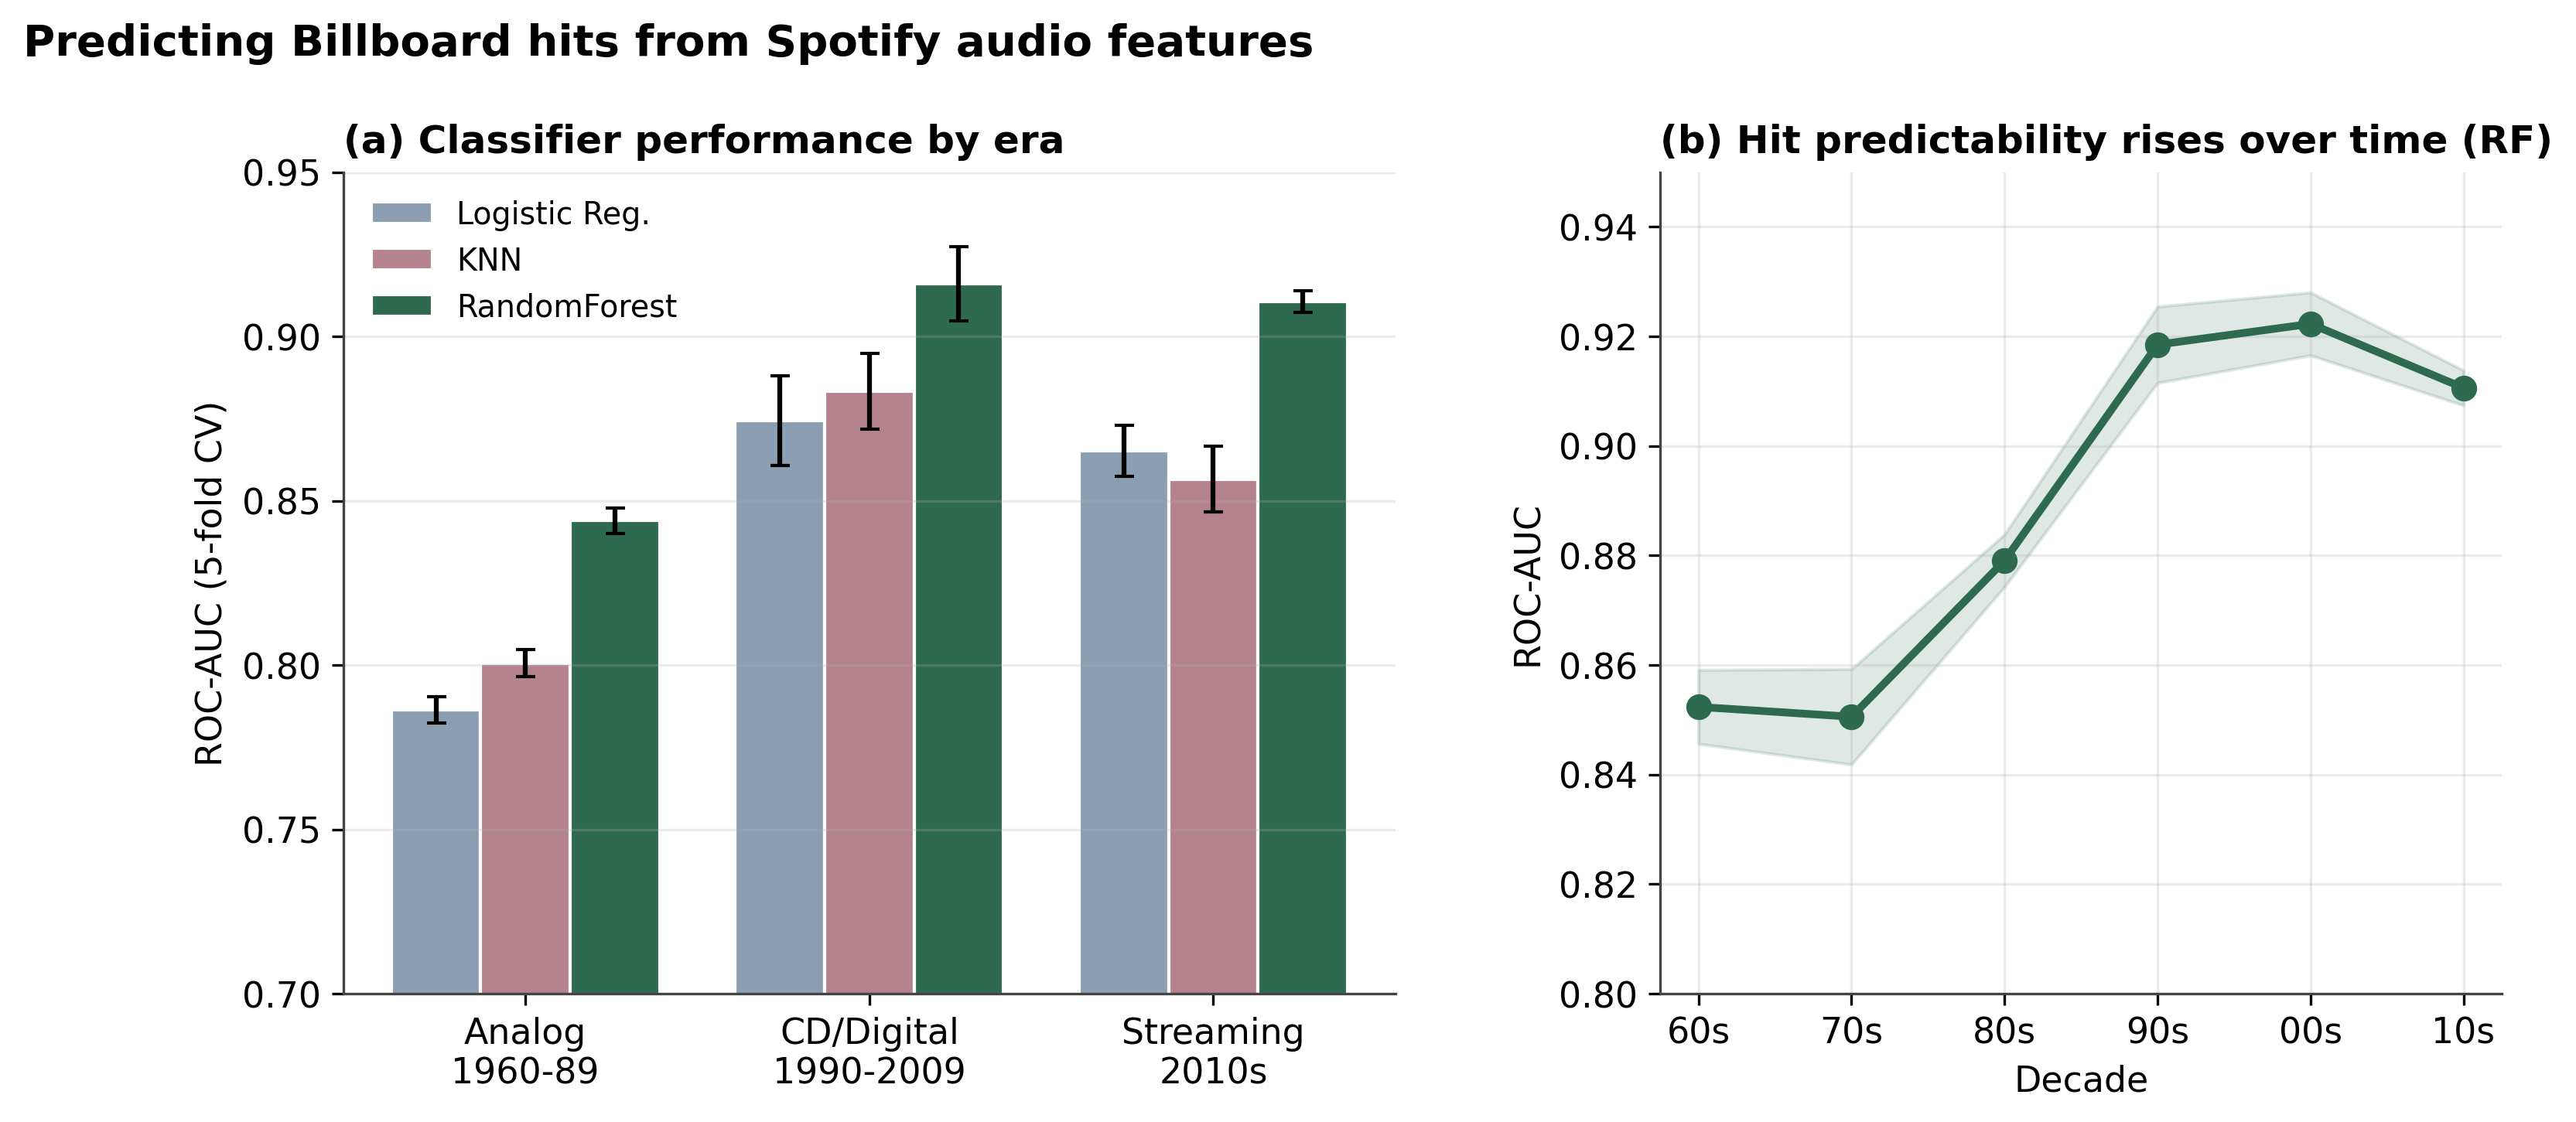

In [2]:
perf = (metrics[metrics.level=='era']
        .pivot_table(index='group', columns='model', values='roc_auc_mean')
        .reindex(ERAS)[['LogReg','KNN','RandomForest']])
perf.columns = ['Logistic Reg.', 'KNN', 'Random Forest']
display(perf.round(3))
display(Image('../figures/fig1_model_performance.png'))

## 2. Feature importance by era (SHAP)
`instrumentalness` is #1 in every era and rising; `loudness` climbs from #5 to #2.

group,Analog (1960-89),CD/Digital (1990-2009),Streaming (2010s)
feature,,,
instrumentalness,0.094,0.118,0.164
acousticness,0.060,0.065,0.049
speechiness,0.055,0.026,0.010
danceability,0.047,0.093,0.058
loudness,0.033,0.040,0.064
energy,0.031,0.029,0.044
valence,0.026,0.018,0.024
duration_ms,0.024,0.067,0.033
mode,0.018,0.006,0.001


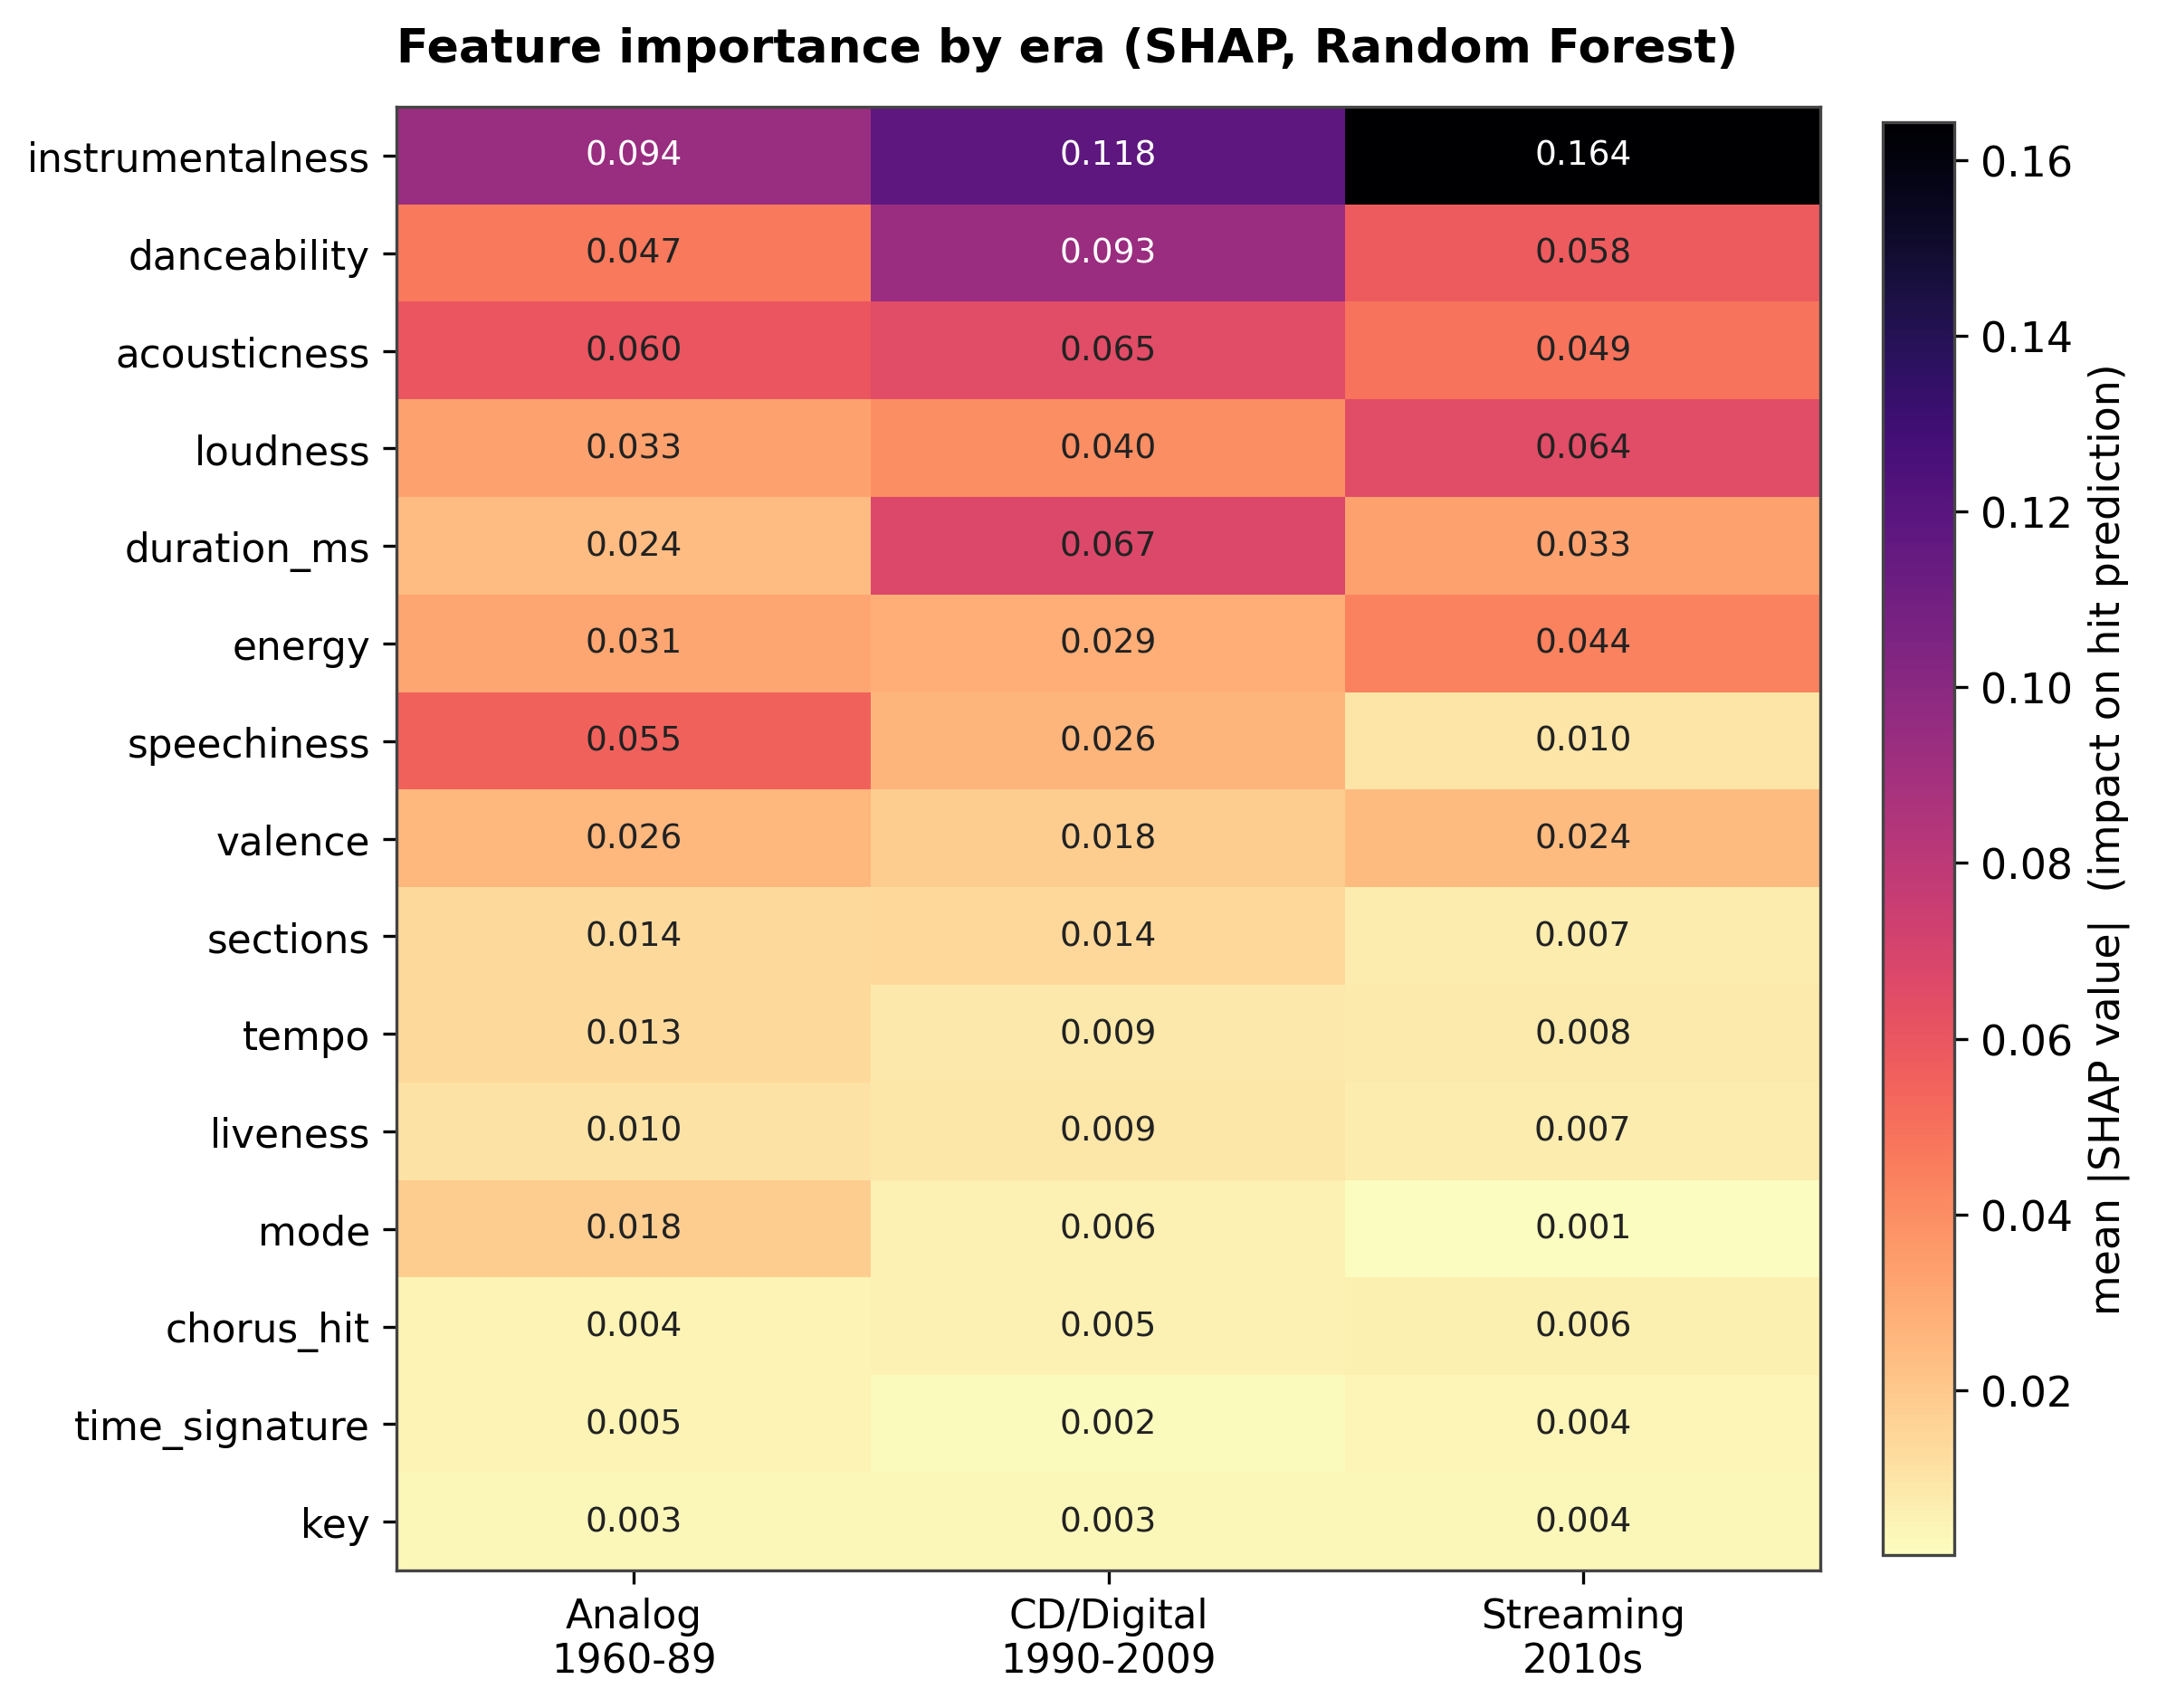

In [3]:
piv = shap_df[shap_df.level=='era'].pivot(index='feature', columns='group', values='mean_abs_shap')[ERAS]
display(piv.sort_values(ERAS[0], ascending=False).round(3))
display(Image('../figures/fig2_shap_heatmap_era.png'))

## 3. How importance shifts across decades

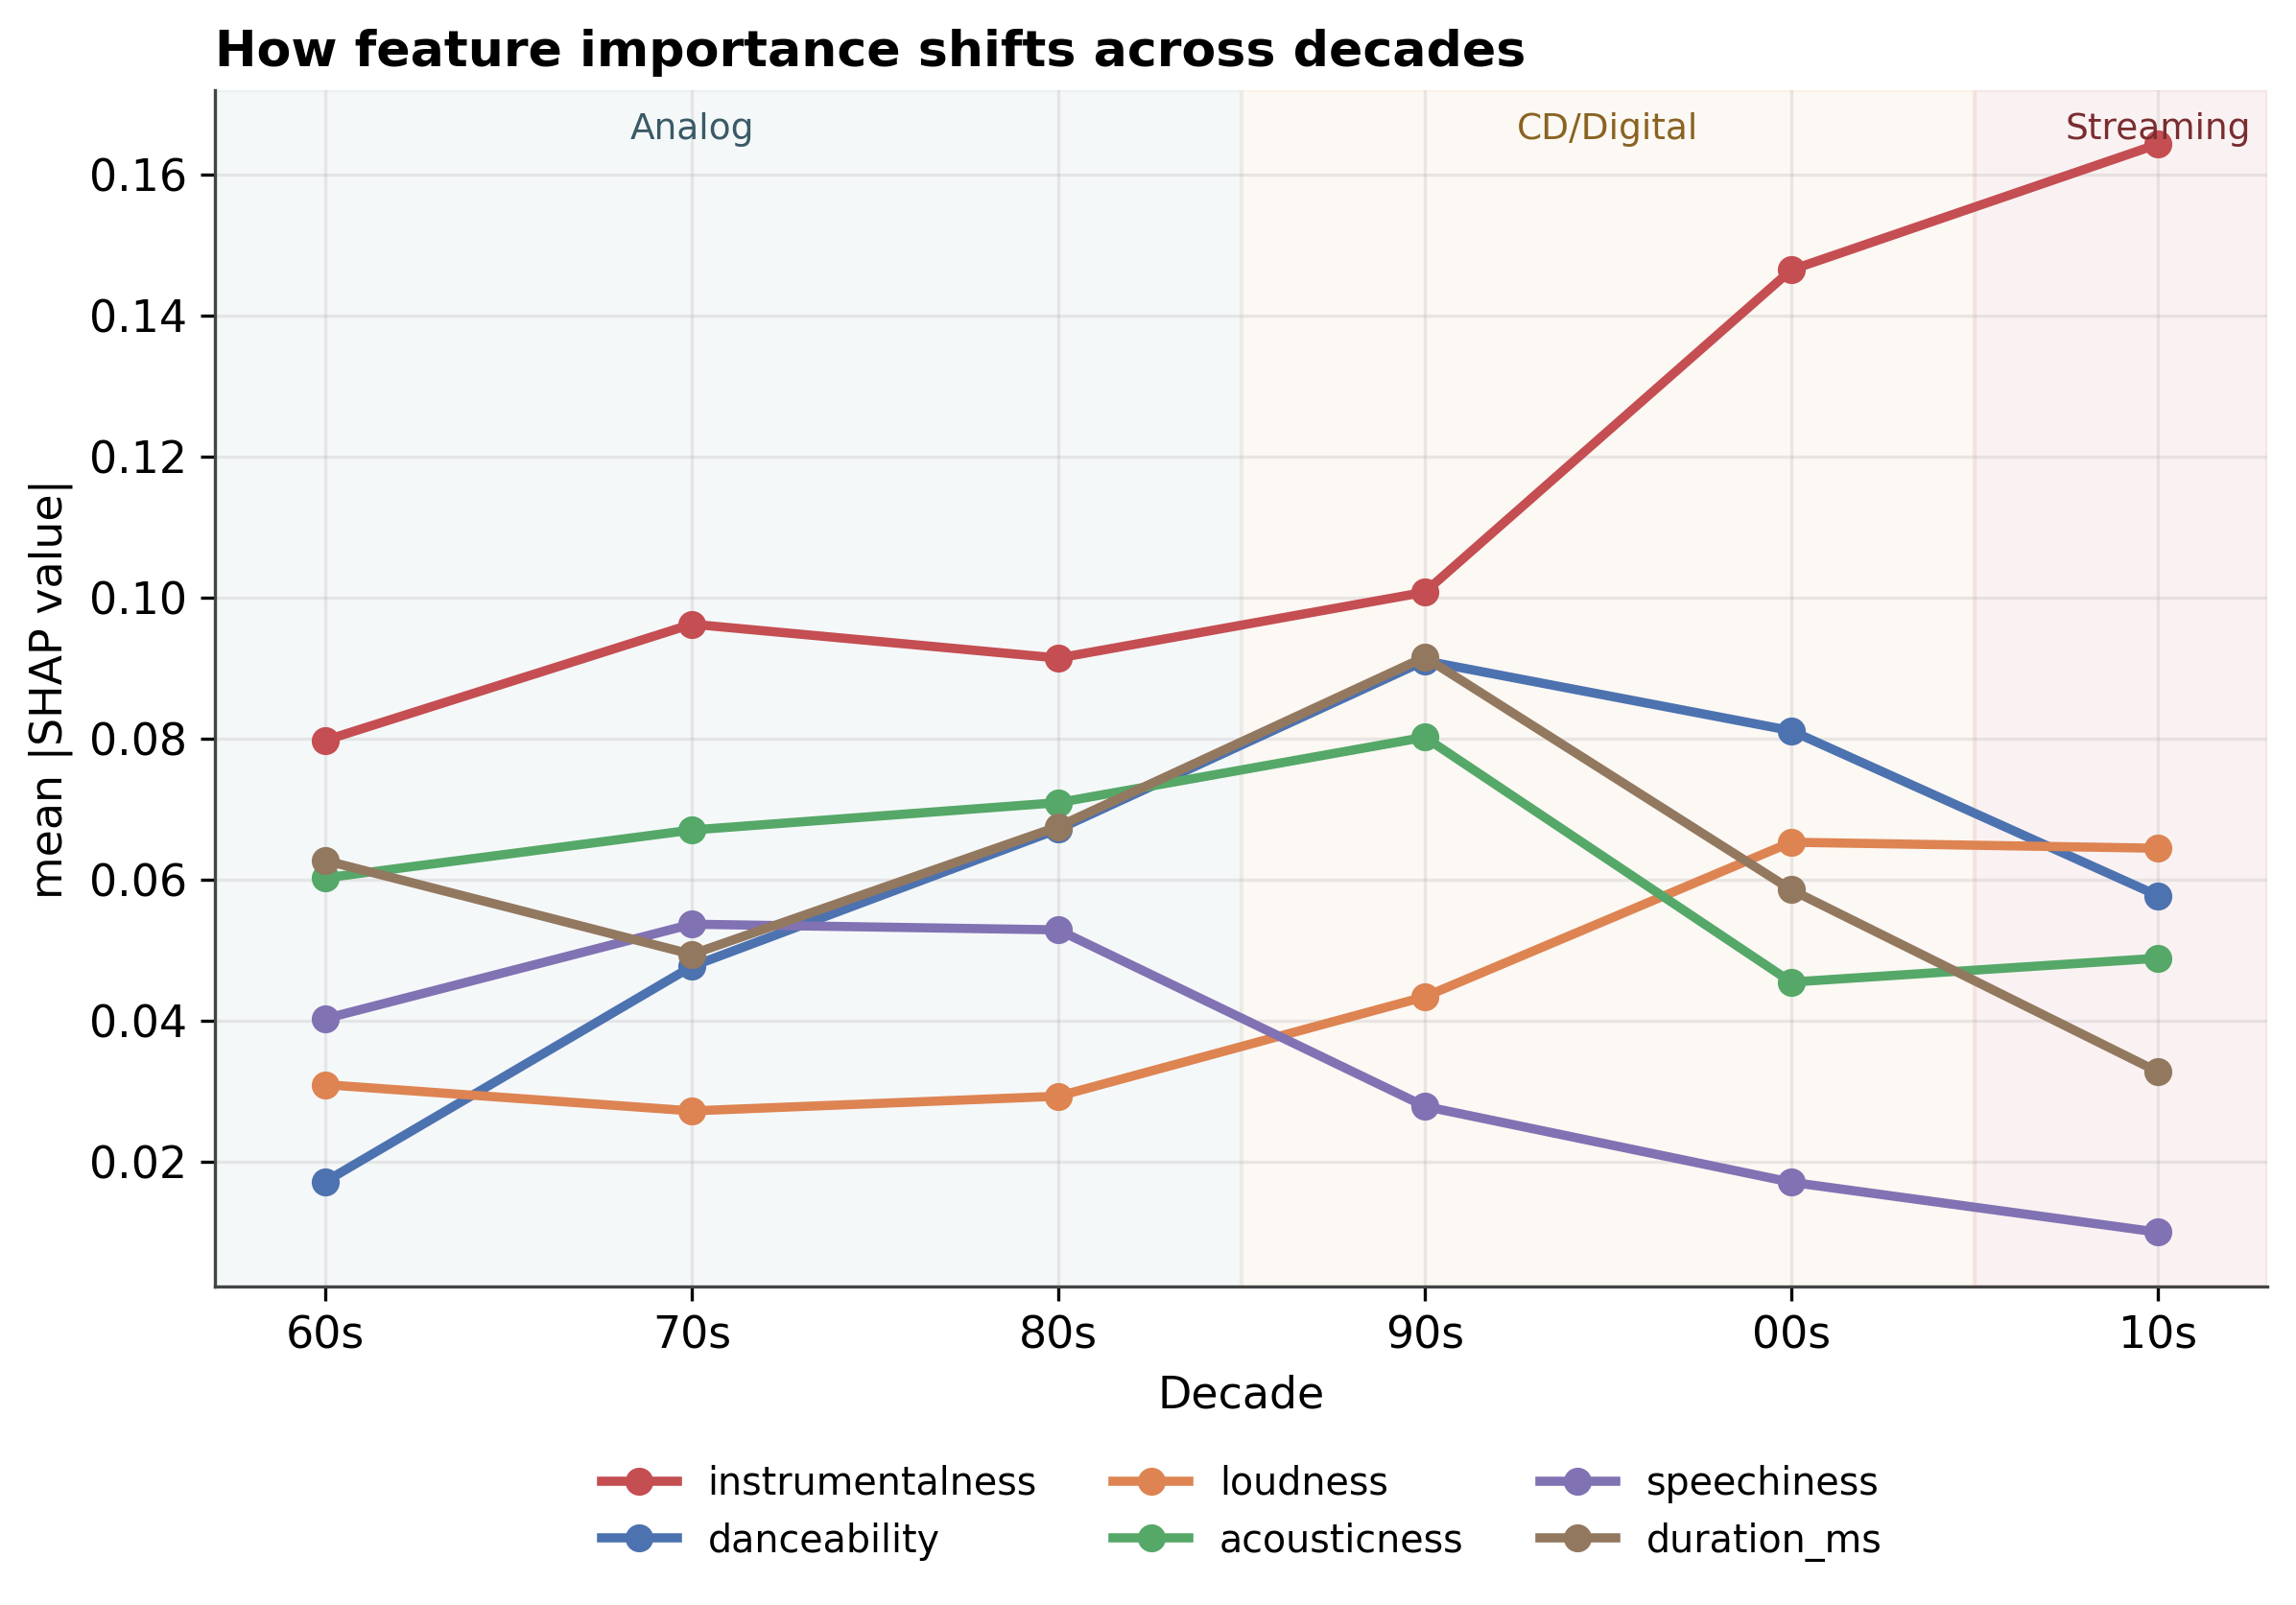

In [4]:
display(Image('../figures/fig3_shap_trend_decade.png'))

## 4. Direction of effect (standardised logistic-regression coefficients)
Green/blue pushes toward HIT, red toward FLOP.

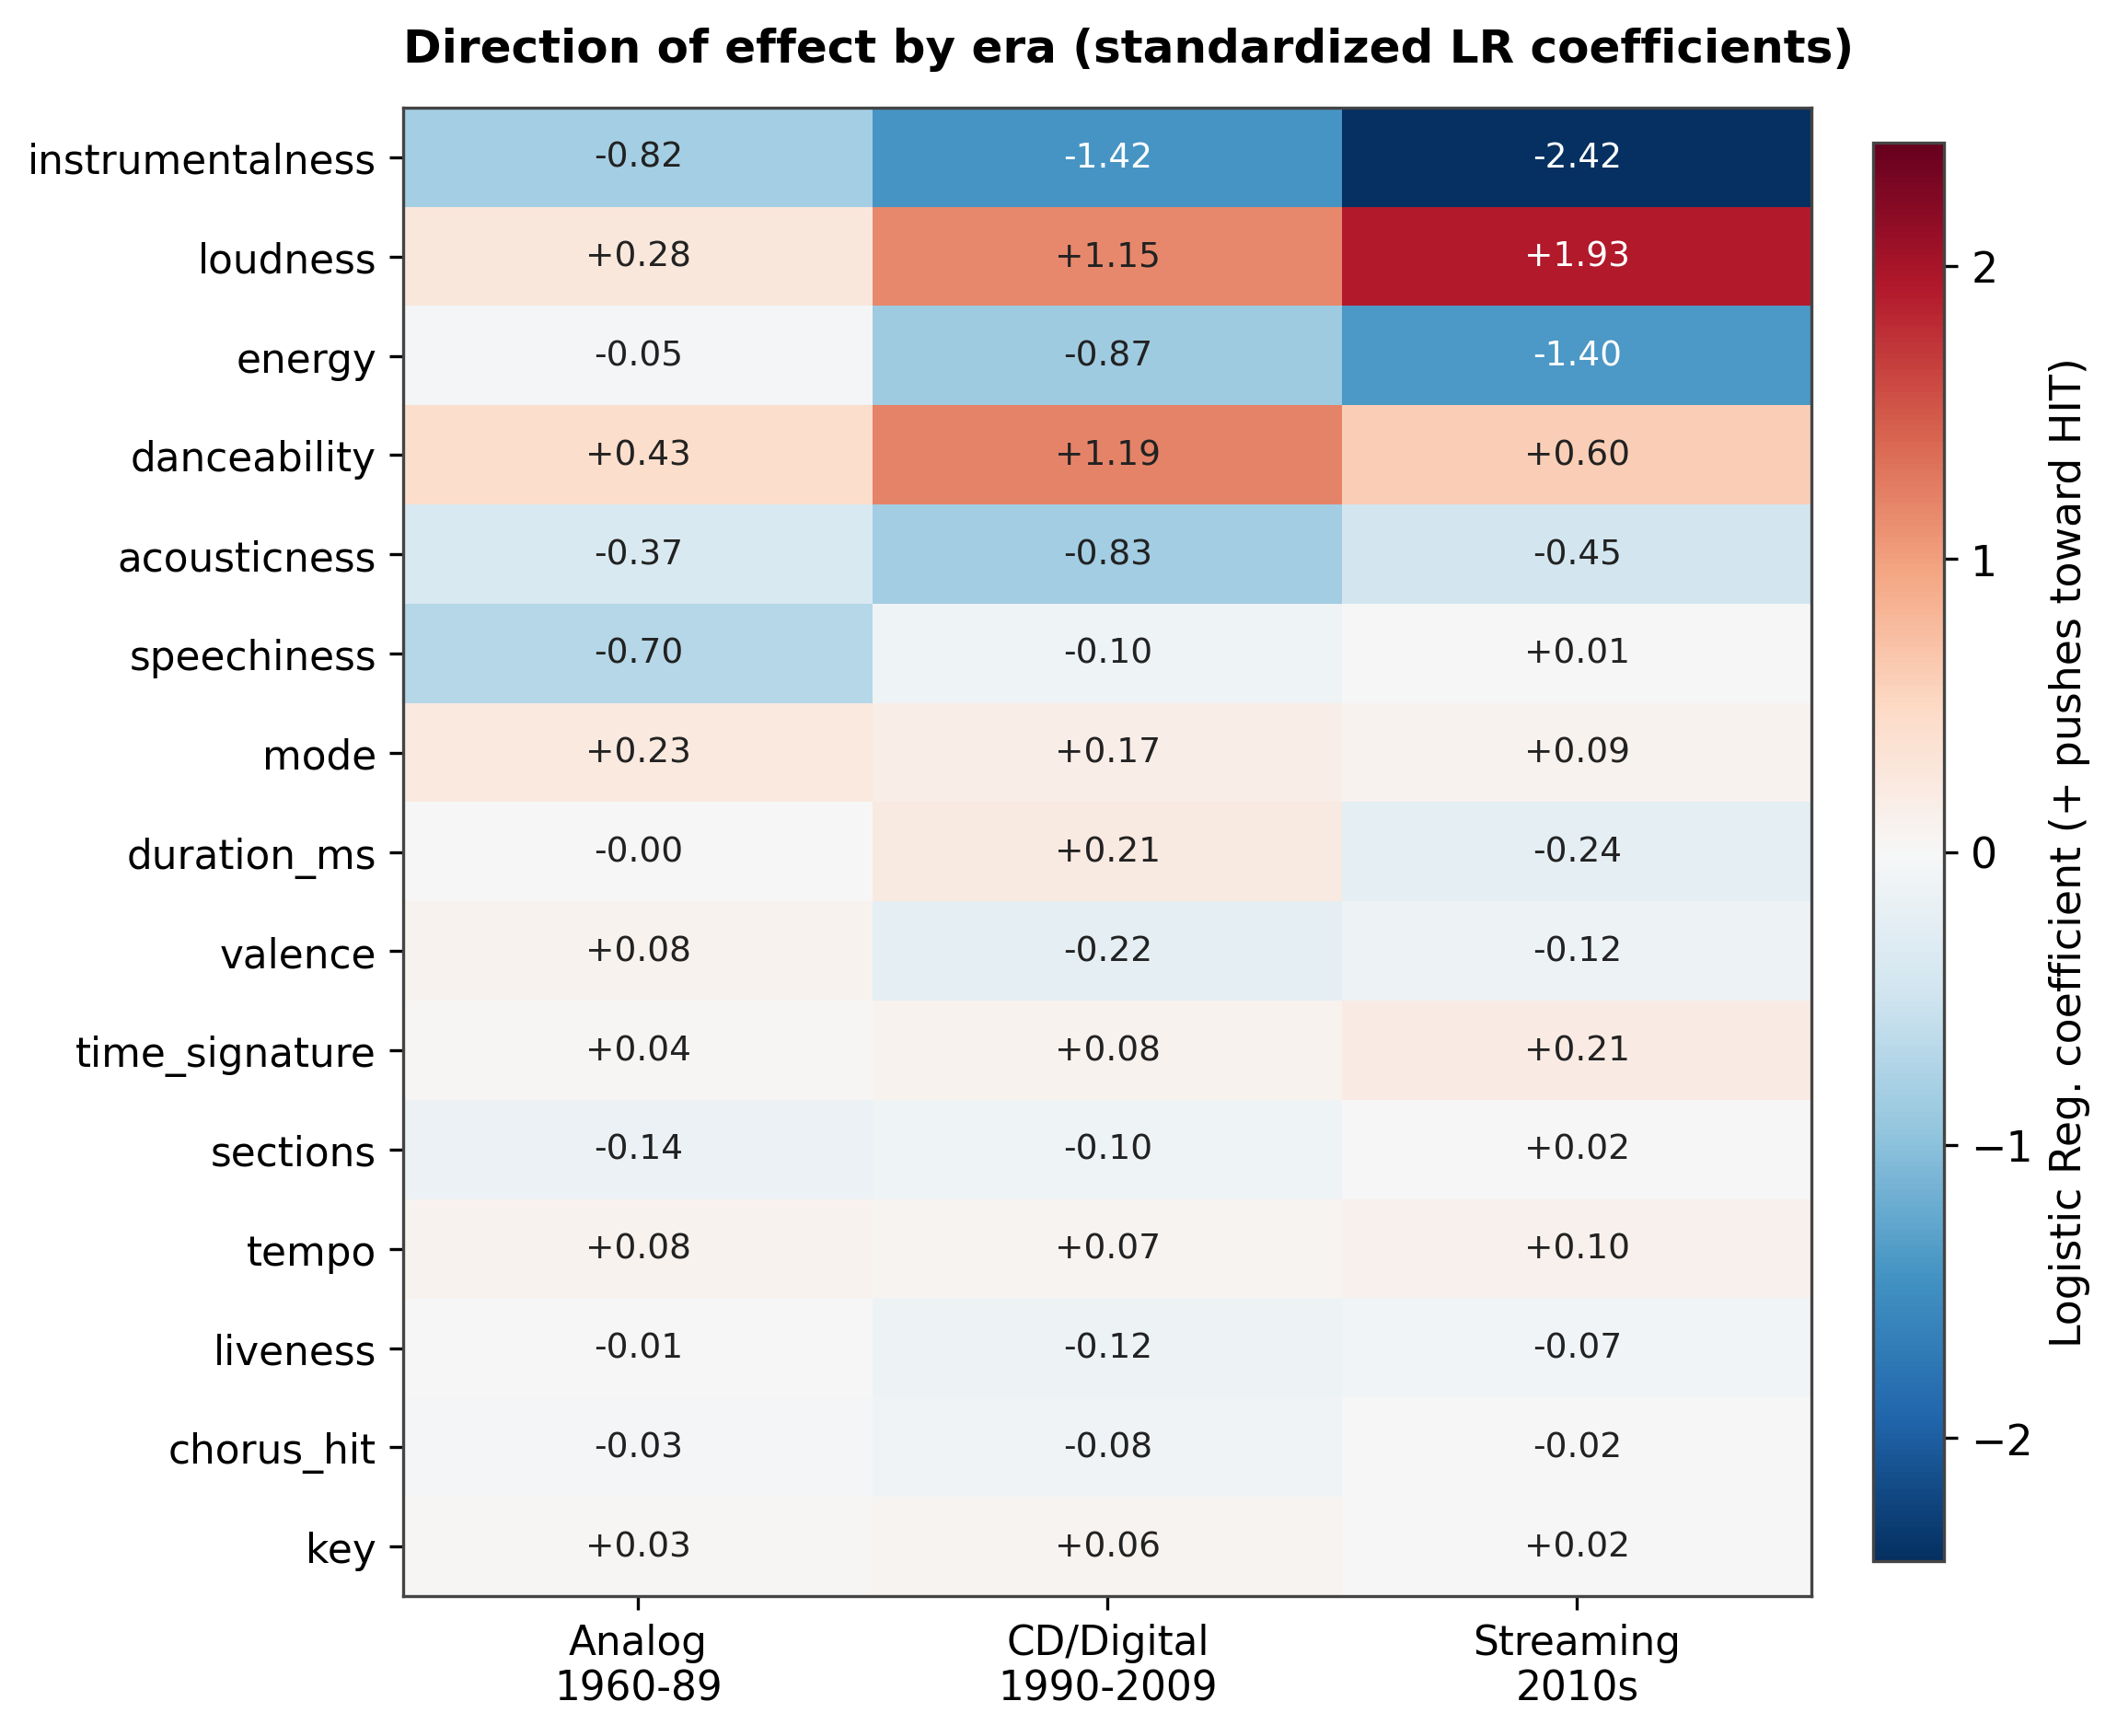

In [5]:
display(Image('../figures/fig4_lr_direction_era.png'))

## 5. SHAP beeswarms by era
Each dot is a track; red = high feature value, right = pushes toward HIT.

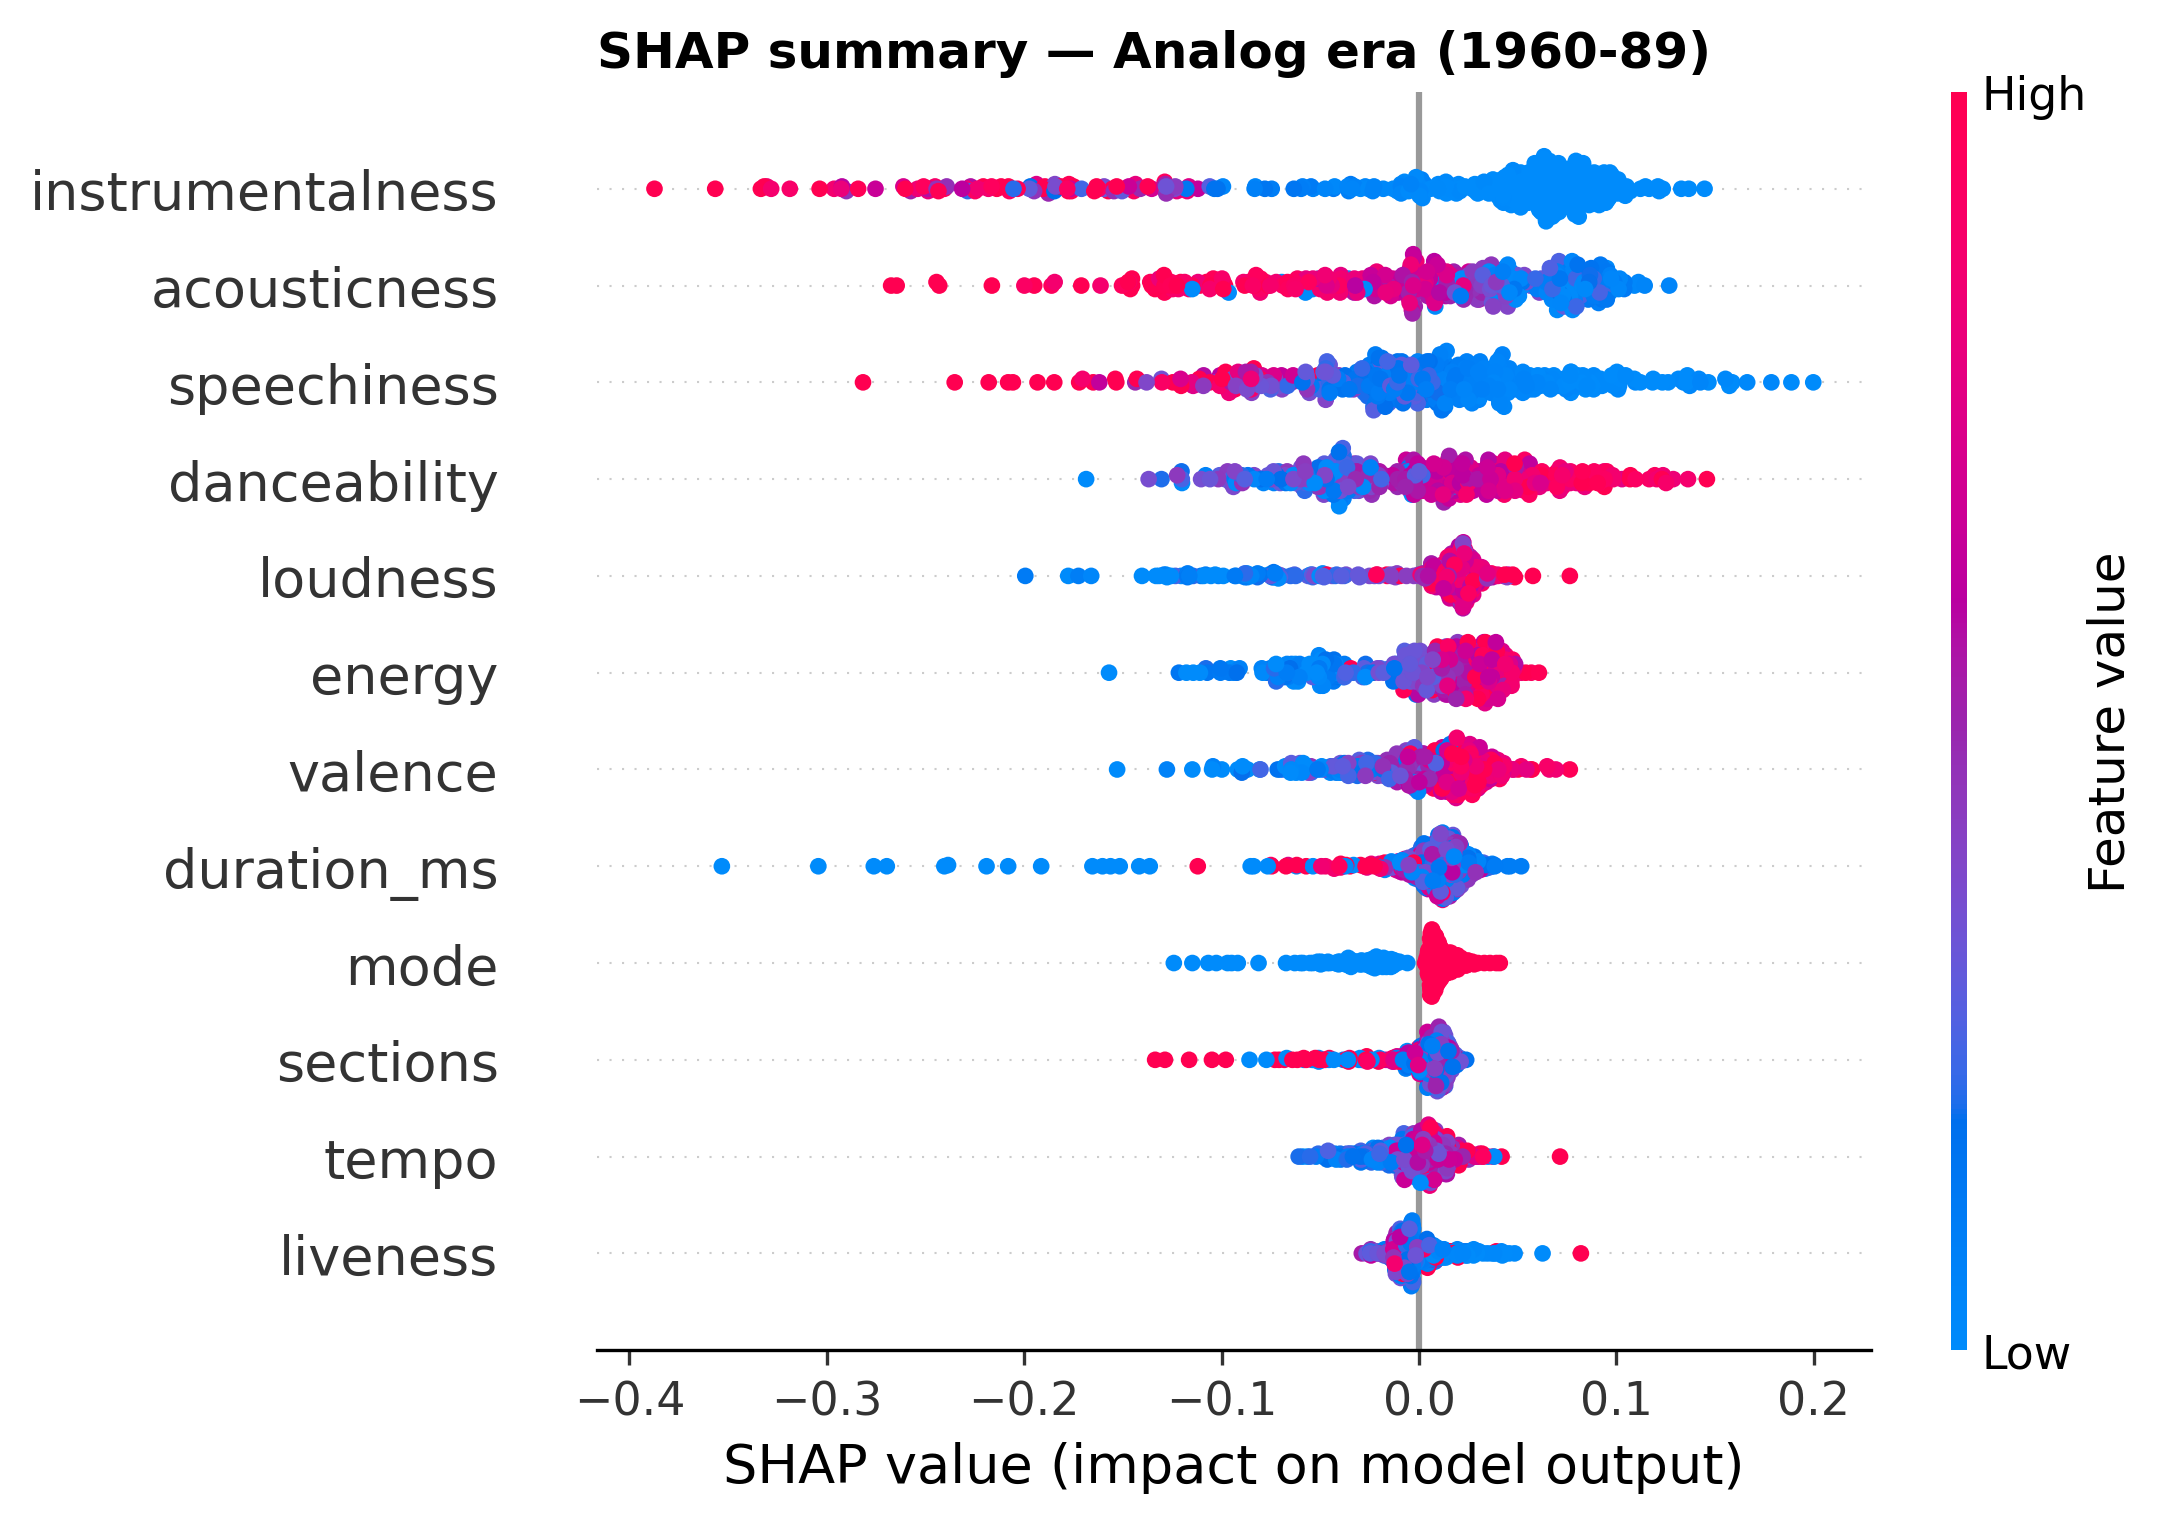

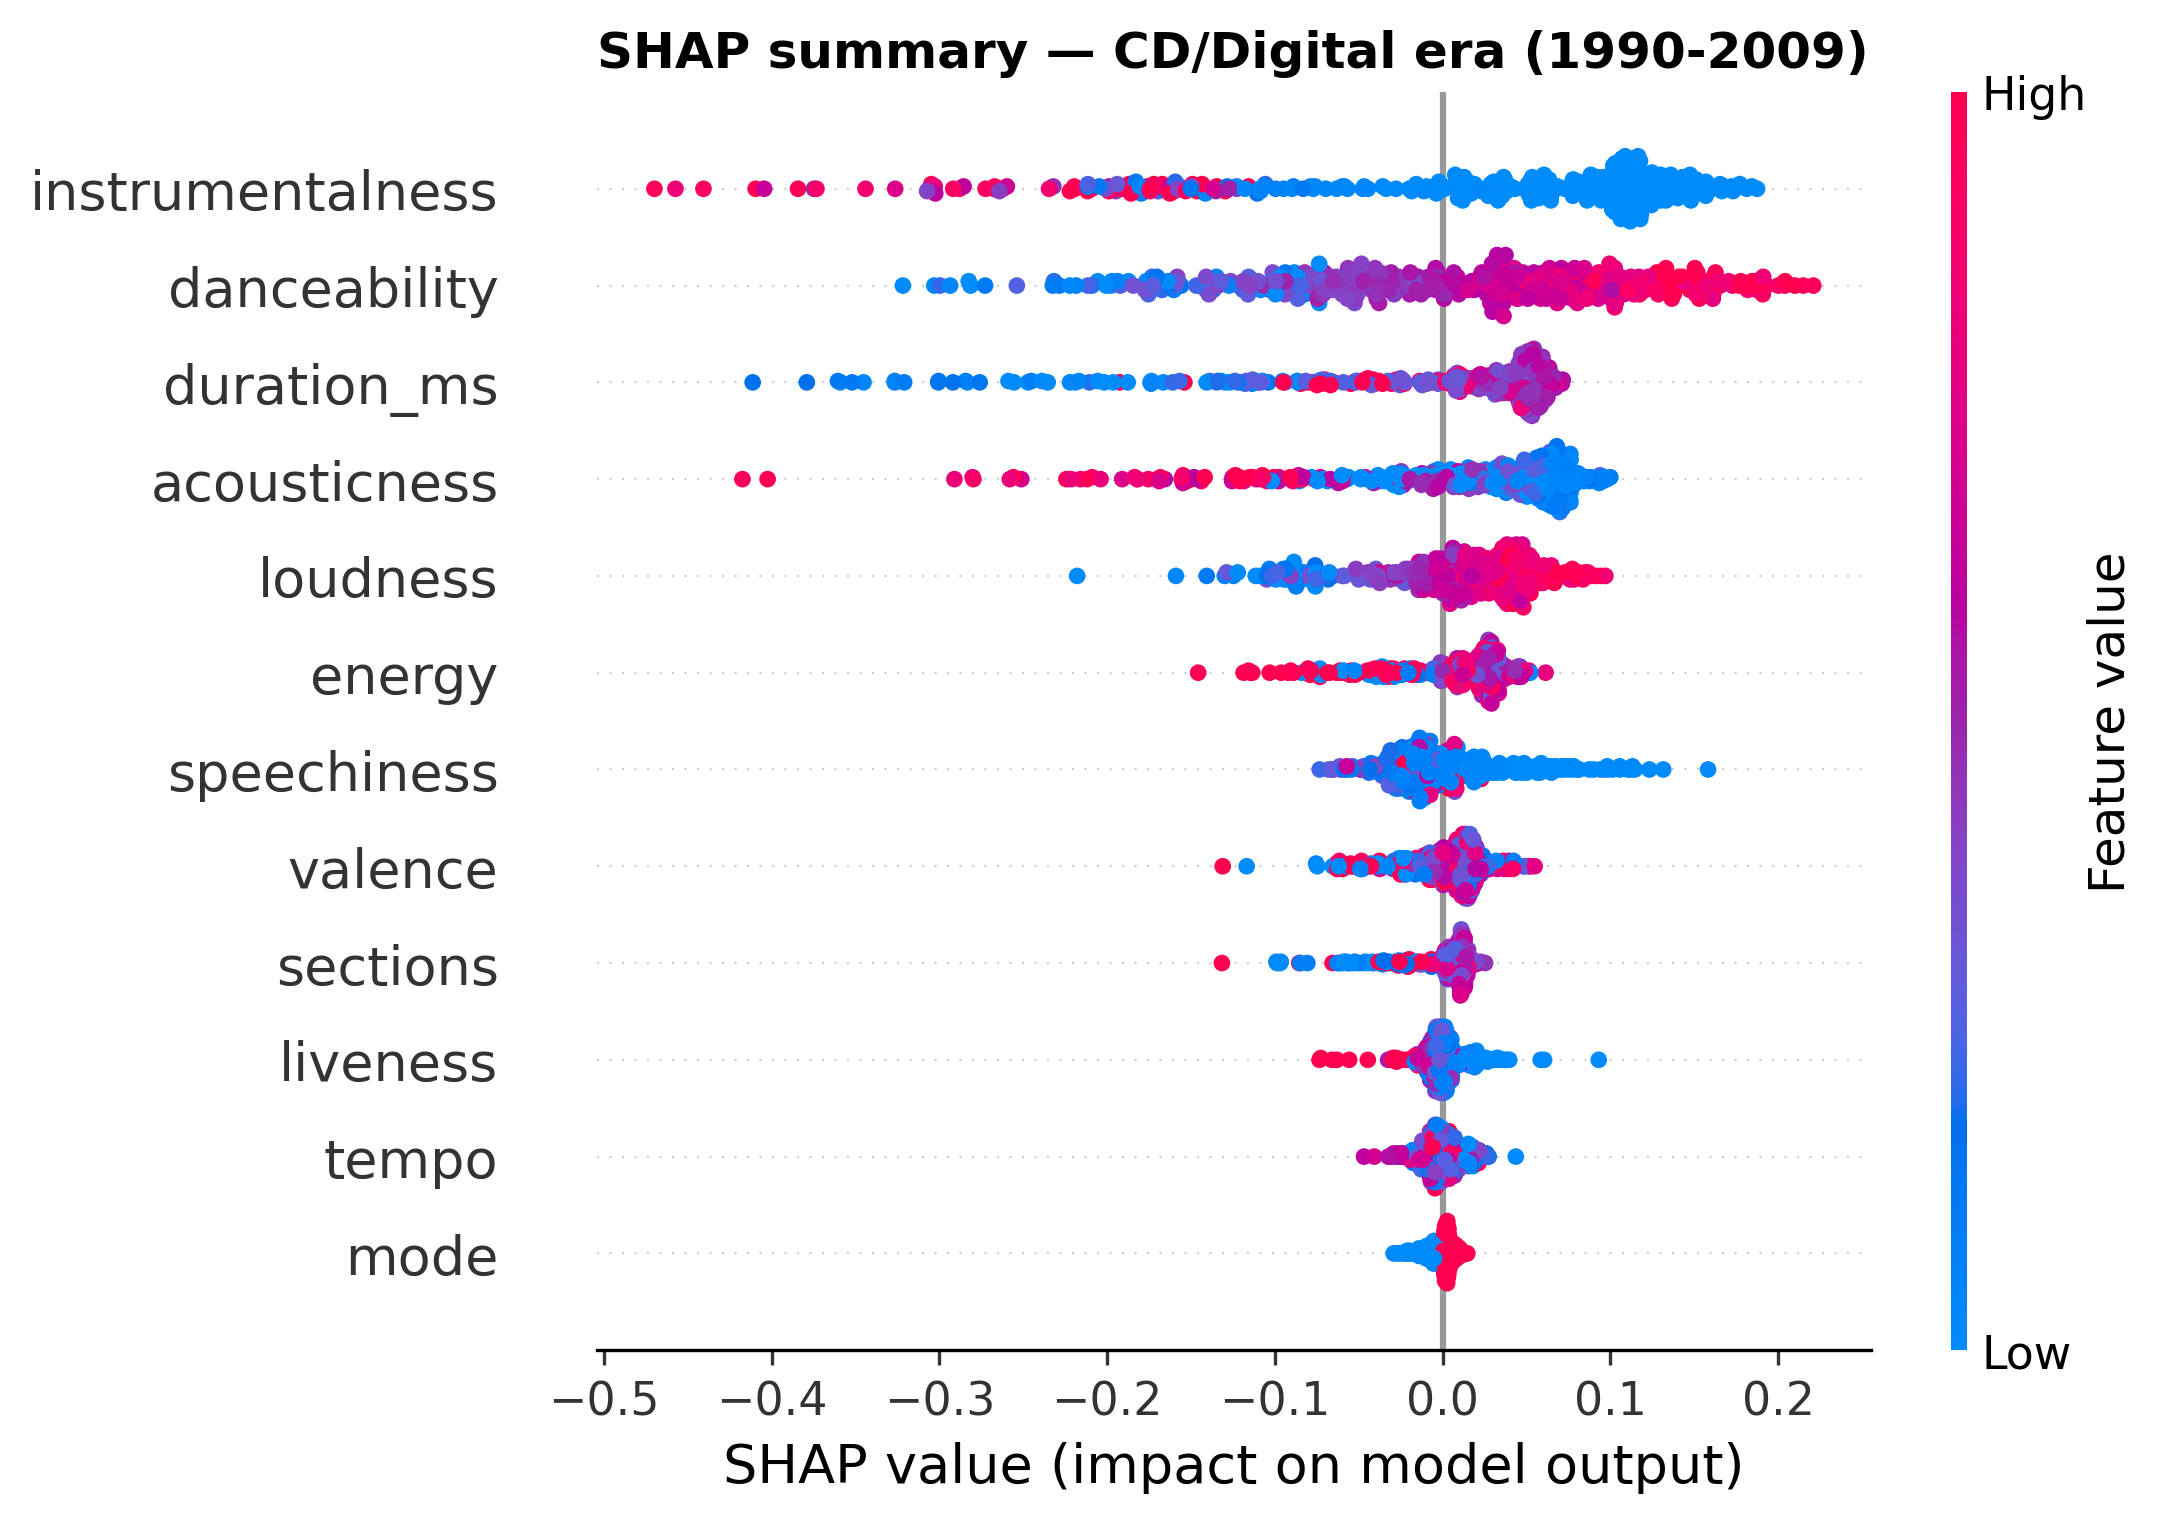

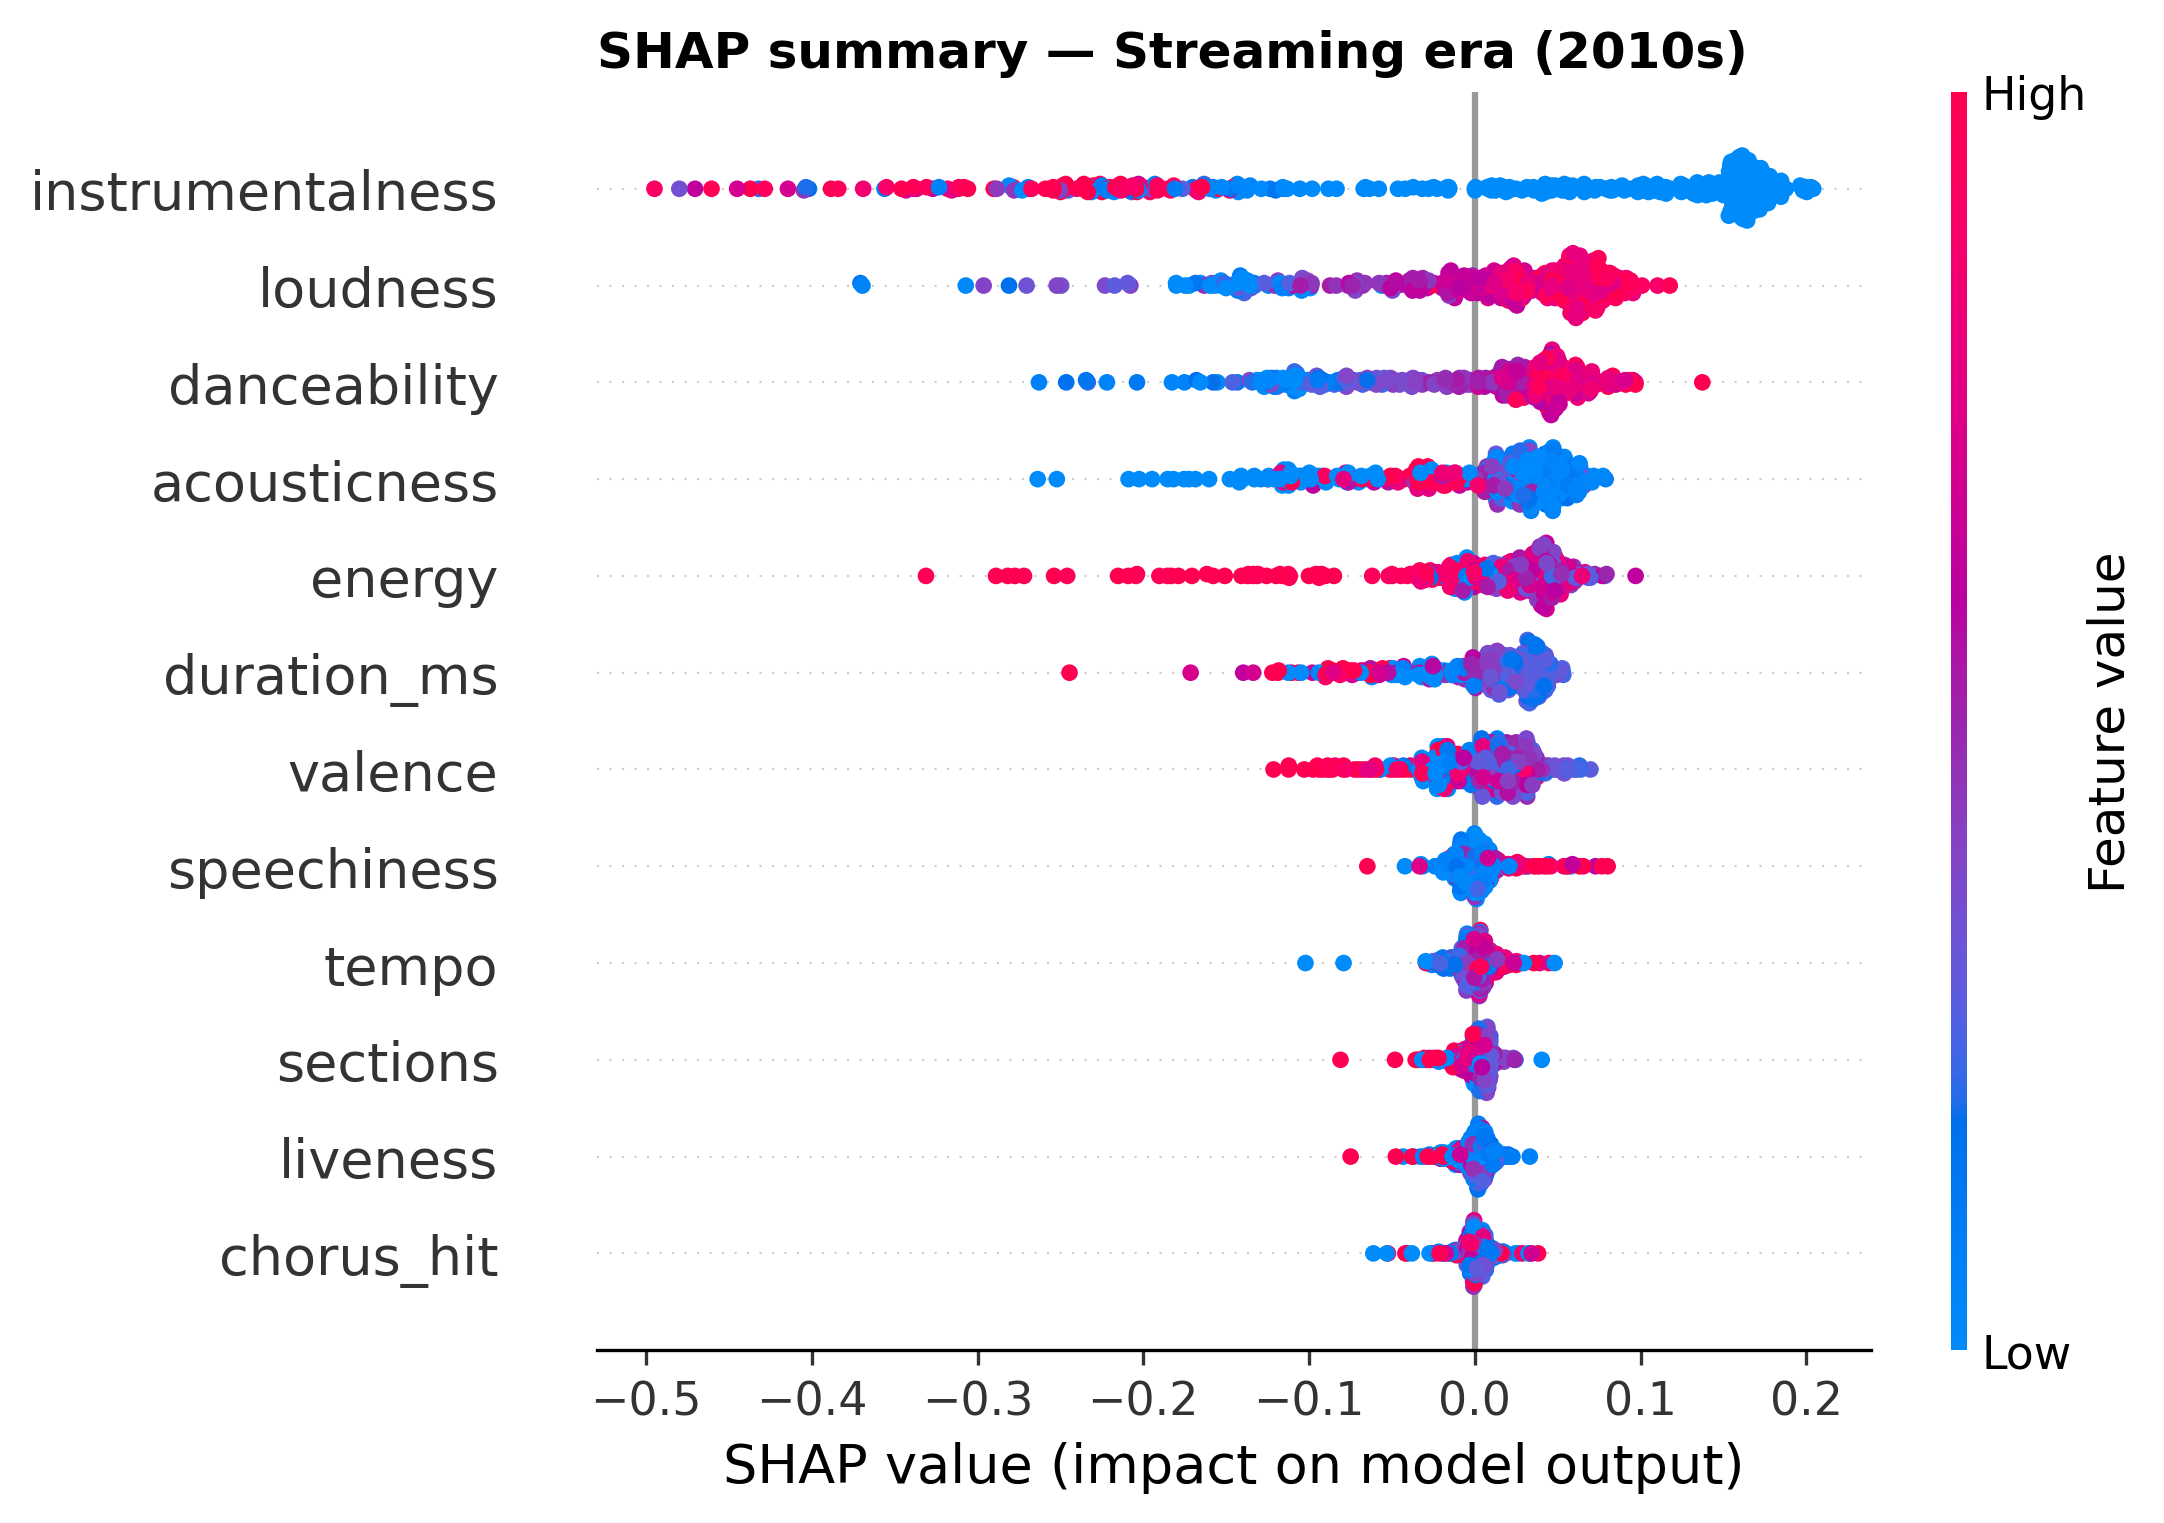

In [6]:
for f in ['../figures/fig5_beeswarm_Analog.png','../figures/fig5_beeswarm_CD_Digital.png','../figures/fig5_beeswarm_Streaming.png']:
    display(Image(f))

## Reproduce
```bash
pip install -r requirements.txt
python spotify_hit_analysis.py
```
Outputs land in `results/` (tables) and `figures/` (PNGs). See `Hit_or_Flop_Analysis.docx` for the full write-up.